Drive Mount and Extract

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
import zipfile
import os

shutil.copy('/content/drive/MyDrive/split_dataset.zip', '/content/split_dataset.zip')
with zipfile.ZipFile('/content/split_dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

DATASET_ROOT = '/content/content/split_dataset'
train_path = os.path.join(DATASET_ROOT, 'train')
val_path = os.path.join(DATASET_ROOT, 'val')
test_path = os.path.join(DATASET_ROOT, 'test')

print(os.listdir(DATASET_ROOT))

Mounted at /content/drive
['test', 'train', 'val']


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True,
    seed=42
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

class_names = train_ds_raw.class_names
num_classes = len(class_names)
print(f"Total classes: {num_classes}")
print(class_names)

train_ds = train_ds_raw.map(lambda x, y: (preprocess_input(x), y)).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds_raw.map(lambda x, y: (preprocess_input(x), y)).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds_raw.map(lambda x, y: (preprocess_input(x), y)).prefetch(tf.data.AUTOTUNE)

Found 18037 files belonging to 15 classes.
Found 2519 files belonging to 15 classes.
Found 2538 files belonging to 15 classes.
Total classes: 15
['Corn', 'Corn_Common_Rust', 'Corn_Gray_Leaf_Spot', 'Corn_Healthy', 'Corn_Leaf_Blight', 'Rice', 'Rice_Bacterial_Leaf_Blight', 'Rice_Brown_Spot', 'Rice_Healthy', 'Rice_Leaf_Blast', 'Wheat', 'Wheat_Brown_Rust', 'Wheat_Healthy', 'Wheat_Loose_Smut', 'Wheat_Yellow_Rust']


In [ ]:
import shutil

for split in ['train', 'val', 'test']:
    for crop in ['Corn', 'Rice', 'Wheat']:
        path = f'{DATASET_ROOT}/{split}/{crop}'
        if os.path.exists(path):
            shutil.rmtree(path)
            print(f"🗑️ Removed: {path}")

print("✅ Cleanup done")

🗑️ Removed: /content/content/split_dataset/train/Corn
🗑️ Removed: /content/content/split_dataset/train/Rice
🗑️ Removed: /content/content/split_dataset/train/Wheat
🗑️ Removed: /content/content/split_dataset/val/Corn
🗑️ Removed: /content/content/split_dataset/val/Rice
🗑️ Removed: /content/content/split_dataset/val/Wheat
🗑️ Removed: /content/content/split_dataset/test/Corn
🗑️ Removed: /content/content/split_dataset/test/Rice
🗑️ Removed: /content/content/split_dataset/test/Wheat
✅ Cleanup done


In [ ]:
import shutil
shutil.make_archive('/content/drive/MyDrive/split_dataset', 'zip', DATASET_ROOT)
print("✅ Clean dataset re-saved to Drive — no more empty-folder issue going forward")

✅ Clean dataset re-saved to Drive — no more empty-folder issue going forward


The tf.data pipeline

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True,
    seed=42
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

class_names = train_ds_raw.class_names
num_classes = len(class_names)
print(f"Total classes: {num_classes}")
print(class_names)

train_ds = train_ds_raw.map(lambda x, y: (preprocess_input(x), y)).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds_raw.map(lambda x, y: (preprocess_input(x), y)).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds_raw.map(lambda x, y: (preprocess_input(x), y)).prefetch(tf.data.AUTOTUNE)

Found 18037 files belonging to 12 classes.
Found 2519 files belonging to 12 classes.
Found 2538 files belonging to 12 classes.
Total classes: 12
['Corn_Common_Rust', 'Corn_Gray_Leaf_Spot', 'Corn_Healthy', 'Corn_Leaf_Blight', 'Rice_Bacterial_Leaf_Blight', 'Rice_Brown_Spot', 'Rice_Healthy', 'Rice_Leaf_Blast', 'Wheat_Brown_Rust', 'Wheat_Healthy', 'Wheat_Loose_Smut', 'Wheat_Yellow_Rust']


Model architecture

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models, regularizers

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # Phase 1: freeze the backbone

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,380,591 (16.71 MB)

 Trainable params: 331,020 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

Callbacks

In [ ]:
os.makedirs('/content/drive/MyDrive/thesis_efficientnet_outputs', exist_ok=True)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    '/content/drive/MyDrive/thesis_efficientnet_outputs/best_efficientnet_model.keras',
    save_best_only=True,
    monitor='val_accuracy'
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7
)

callbacks = [early_stop, checkpoint, reduce_lr]

Phase 1 training (frozen backbone)

In [ ]:
history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 141s 191ms/step - accuracy: 0.8208 - loss: 0.8838 - val_accuracy: 0.9190 - val_loss: 0.5329 - learning_rate: 0.0010
Epoch 2/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 48s 86ms/step - accuracy: 0.8791 - loss: 0.5928 - val_accuracy: 0.9297 - val_loss: 0.4279 - learning_rate: 0.0010
Epoch 3/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 46s 81ms/step - accuracy: 0.8880 - loss: 0.5302 - val_accuracy: 0.9341 - val_loss: 0.4086 - learning_rate: 0.0010
Epoch 4/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 81s 80ms/step - accuracy: 0.8955 - loss: 0.5017 - val_accuracy: 0.9309 - val_loss: 0.4032 - learning_rate: 0.0010
Epoch 5/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 49s 87ms/step - accuracy: 0.8972 - loss: 0.4946 - val_accuracy: 0.9321 - val_loss: 0.3919 - learning_rate: 0.0010
Epoch 6/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 45s 79ms/step - accuracy: 0.9018 - loss: 0.4891 - val_accuracy: 0.9329 - val_loss: 0.3925 - learning_rate: 0.0010
Epoch 7/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 85s 84ms/step - accuracy: 0.9041 -

Phase 2 training (fine-tuning)

In [ ]:
base_model.trainable = True

fine_tune_at = int(len(base_model.layers) * 0.7)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 121s 147ms/step - accuracy: 0.8274 - loss: 0.7316 - val_accuracy: 0.9357 - val_loss: 0.4267 - learning_rate: 1.0000e-05
Epoch 2/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 51s 91ms/step - accuracy: 0.8888 - loss: 0.5353 - val_accuracy: 0.9448 - val_loss: 0.3880 - learning_rate: 1.0000e-05
Epoch 3/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 78s 85ms/step - accuracy: 0.9090 - loss: 0.4801 - val_accuracy: 0.9504 - val_loss: 0.3682 - learning_rate: 1.0000e-05
Epoch 4/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 51s 91ms/step - accuracy: 0.9233 - loss: 0.4431 - val_accuracy: 0.9539 - val_loss: 0.3548 - learning_rate: 1.0000e-05
Epoch 5/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 48s 85ms/step - accuracy: 0.9302 - loss: 0.4181 - val_accuracy: 0.9587 - val_loss: 0.3439 - learning_rate: 1.0000e-05
Epoch 6/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 51s 90ms/step - accuracy: 0.9403 - loss: 0.3909 - val_accuracy: 0.9579 - val_loss: 0.3349 - learning_rate: 1.0000e-05
Epoch 7/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 80s 87ms/s

Test result

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

80/80 ━━━━━━━━━━━━━━━━━━━━ 19s 237ms/step - accuracy: 0.9768 - loss: 0.2675
Test Loss: 0.2675
Test Accuracy: 0.9768


Classification Report

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

                            precision    recall  f1-score   support

          Corn_Common_Rust       0.99      0.97      0.98       197
       Corn_Gray_Leaf_Spot       0.95      0.93      0.94       177
              Corn_Healthy       0.99      1.00      1.00       175
          Corn_Leaf_Blight       0.93      0.94      0.94       173
Rice_Bacterial_Leaf_Blight       0.98      0.99      0.99       294
           Rice_Brown_Spot       0.99      0.97      0.98       271
              Rice_Healthy       0.99      1.00      0.99       331
           Rice_Leaf_Blast       0.96      0.96      0.96       257
          Wheat_Brown_Rust       0.97      0.98      0.98       184
             Wheat_Healthy       1.00      0.98      0.99       207
          Wheat_Loose_Smut       0.98      0.99      0.98        80
         Wheat_Yellow_Rust       0.98      0.99      0.98       192

                  accuracy                           0.98      2538
                 macro avg       0.98      0.9

 Confusion Matrix

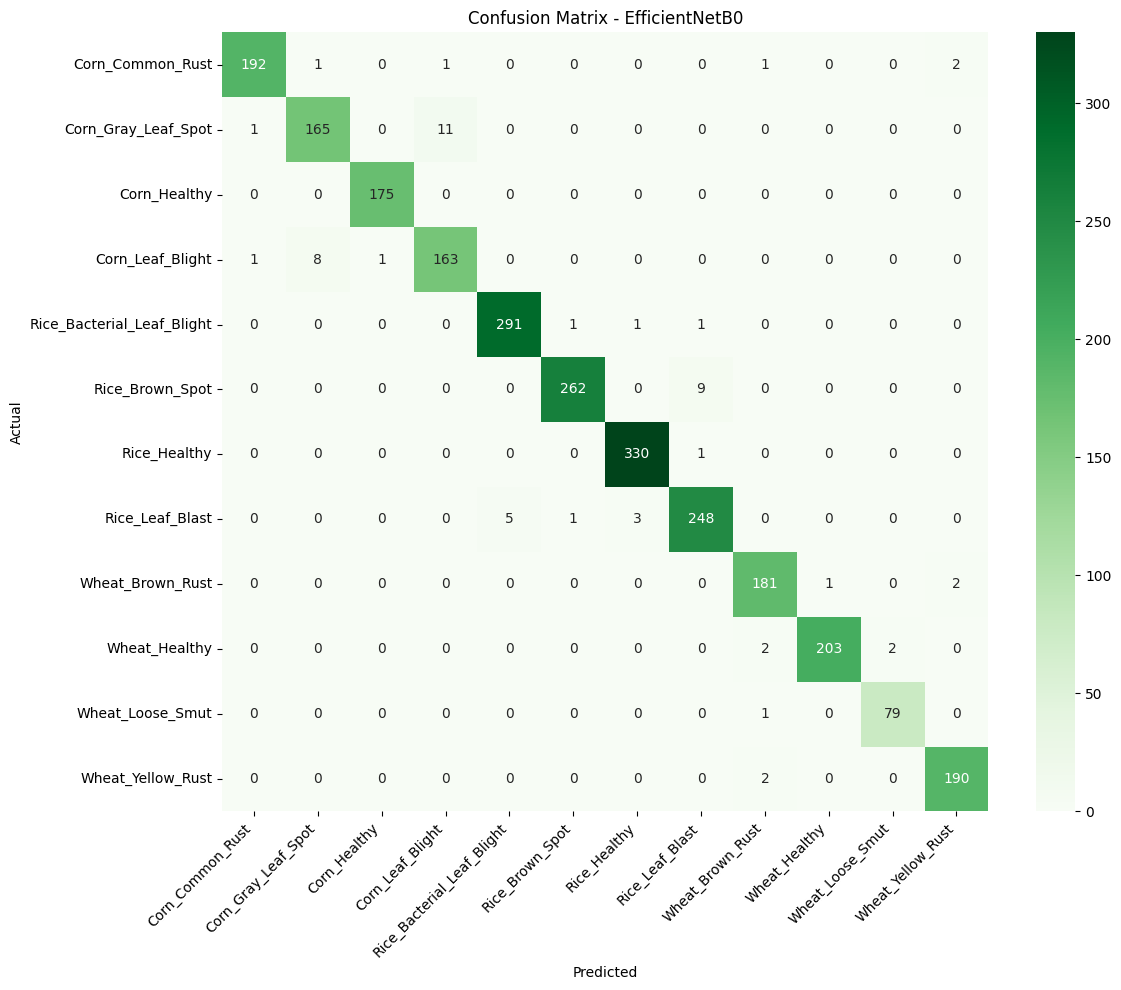

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# y_true, y_pred already generated in Cell 8 (classification report step)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - EfficientNetB0')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/thesis_efficientnet_outputs/confusion_matrix.png', dpi=150)
plt.show()

Model size, parameters, inference time

In [ ]:
import os
import time
import numpy as np

# --- Model size ---
model_path = '/content/drive/MyDrive/thesis_efficientnet_outputs/best_efficientnet_model.keras'
model_size_mb = os.path.getsize(model_path) / (1024 * 1024)
print(f"📦 Model file size: {model_size_mb:.2f} MB")

# --- Parameter count ---
total_params = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"🔢 Total parameters: {total_params:,}")
print(f"🔢 Trainable parameters: {trainable_params:,}")

# --- Inference time ---
sample_batch = next(iter(test_ds))[0][:1]  # take 1 image
_ = model.predict(sample_batch, verbose=0)  # warm-up run

n_runs = 50
start = time.time()
for _ in range(n_runs):
    _ = model.predict(sample_batch, verbose=0)
end = time.time()

avg_inference_ms = ((end - start) / n_runs) * 1000
print(f"⏱️ Average inference time: {avg_inference_ms:.2f} ms/image")

# --- Summary ---
print("\n" + "=" * 60)
print("SUMMARY FOR COMPARISON TABLE")
print("=" * 60)
print(f"Model size (MB):       {model_size_mb:.2f}")
print(f"Total parameters:      {total_params:,}")
print(f"Inference time (ms):   {avg_inference_ms:.2f}")

📦 Model file size: 43.58 MB
🔢 Total parameters: 4,380,591
🔢 Trainable parameters: 3,410,152
⏱️ Average inference time: 76.10 ms/image

SUMMARY FOR COMPARISON TABLE
Model size (MB):       43.58
Total parameters:      4,380,591
Inference time (ms):   76.10


Single image prediction

In [ ]:
import numpy as np
from tensorflow.keras.applications.efficientnet import preprocess_input
from google.colab import files

# Upload an image
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Preprocess (must match EfficientNet's own preprocessing)
img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# Predict
preds = model.predict(img_array, verbose=0)[0]
predicted_class = class_names[np.argmax(preds)]
confidence = np.max(preds) * 100

print(f"Predicted class: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")

Saving Corn_Common_Rust97.JPG to Corn_Common_Rust97.JPG
Predicted class: Corn_Common_Rust
Confidence: 100.00%
